In [1]:
import pandas as pd
from pathlib import Path

from env_pricing_sample import PricingEnv  

from stable_baselines3 import PPO

# Load RL panel created in 01_data_prep_eda
panel_path = Path("rl_panel.parquet")
df = pd.read_parquet(panel_path)

print("RL panel shape:", df.shape)
display(df.head())


RL panel shape: (590, 13)


,date,base_demand,promo_frac,num_records,footfall,dcoilwtico,is_holiday,dow,weekofyear,month,year,bd_7d_mean,bd_7d_std
0,2016-01-02,259.811,0.016393,61,1725.5,47.00,0,5,53,1,2016,259.811000,NaN
1,2016-01-03,138.275,0.025000,40,1725.5,47.00,0,6,53,1,2016,199.043000,85.938930
2,2016-01-04,552.172,0.000000,74,10.0,36.81,0,0,1,1,2016,316.752667,212.742677
3,2016-01-05,461.738,0.000000,72,1840.0,35.97,0,1,1,1,2016,352.999000,188.223673
4,2016-01-06,546.093,0.000000,72,1996.0,33.97,0,2,1,1,2016,391.617800,184.467265


In [2]:
# Create a single PricingEnv instance

env = PricingEnv(
    df=df,
    price_multipliers=[0.5, 0.7, 1.0, 1.1],  # discount grid
    base_price=1.0,
    elasticity=0.8,
    shelf_life=3,
    safety_stock_factor=1.3,
    waste_penalty=2.0,
    max_inventory=5000,
    random_seed=42,
)

obs, info = env.reset()
print("Initial obs:", obs)
print("Initial info:", info)

# Roll out a short random episode to see if waste is non-zero sometimes
total_revenue = 0.0
total_waste = 0.0

for t in range(30):  # 30 days
    action = env.action_space.sample()       # random action
    obs, reward, done, truncated, info = env.step(action)

    total_revenue += info["revenue"]
    total_waste += info["waste"]

    print(
        f"Day {t} | action={action} | "
        f"price={info['effective_price']:.2f} | "
        f"sold={info['sold']} | waste={info['waste']} | "
        f"reward={reward:.2f}"
    )

    if done:
        print("Episode finished early.")
        break

print("\nRandom policy: total_revenue =", total_revenue, ", total_waste =", total_waste)


Initial obs: [0.37547475 0.05259563 0.5693661  0.73559564 0.         0.8333333
 0.         0.0674     0.6666667 ]
Initial info: {}
Day 0 | action=0 | price=0.50 | sold=437 | waste=0 | reward=218.50
Day 1 | action=0 | price=0.50 | sold=243 | waste=0 | reward=121.50
Day 2 | action=1 | price=0.70 | sold=324 | waste=0 | reward=226.80
Day 3 | action=2 | price=1.00 | sold=531 | waste=0 | reward=531.00
Day 4 | action=2 | price=1.00 | sold=602 | waste=0 | reward=602.00
Day 5 | action=3 | price=1.10 | sold=406 | waste=0 | reward=446.60
Day 6 | action=3 | price=1.10 | sold=391 | waste=0 | reward=430.10
Day 7 | action=1 | price=0.70 | sold=471 | waste=0 | reward=329.70
Day 8 | action=2 | price=1.00 | sold=112 | waste=1 | reward=110.00
Day 9 | action=2 | price=1.00 | sold=515 | waste=374 | reward=-233.00
Day 10 | action=0 | price=0.50 | sold=595 | waste=0 | reward=297.50
Day 11 | action=1 | price=0.70 | sold=620 | waste=0 | reward=434.00
Day 12 | action=2 | price=1.00 | sold=394 | waste=0 | reward

In [3]:
from stable_baselines3.common.env_util import DummyVecEnv

def make_env():
    def _init():
        return PricingEnv(
            df=df,
            price_multipliers=[0.5, 0.7, 1.0, 1.1],
            base_price=1.0,
            elasticity=0.8,
            shelf_life=3,
            safety_stock_factor=1.3,
            waste_penalty=2.0,
            max_inventory=5000,
            random_seed=42,
        )
    return _init

vec_env = DummyVecEnv([make_env()])


In [4]:
model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    n_steps=256,
    batch_size=256,
    ent_coef=0.01,
)

# This might take some minutes depending on your machine
model.learn(total_timesteps=200_000)

model.save("ppo_pricing_model")
print("✅ Model saved: ppo_pricing_model.zip")


Using cpu device
----------------------------
| time/              |     |
|    fps             | 312 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 282         |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 5.62286e-07 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.39       |
|    explained_variance   | -1.79e-05   |
|    learning_rate        | 0.0003      |
|    loss                 | 1.53e+07    |
|    n_updates            | 10          |
|    policy_gradient_loss | -7.78e-05   |
|    value_loss           | 3.05e+07    |
-----------------------------------------
------------------------

In [5]:
# Fresh environment for evaluation
eval_env = PricingEnv(
    df=df,
    price_multipliers=[0.5, 0.7, 1.0, 1.1],
    base_price=1.0,
    elasticity=0.8,
    shelf_life=3,
    safety_stock_factor=1.3,
    waste_penalty=2.0,
    max_inventory=5000,
    random_seed=123,
)

obs, info = eval_env.reset()
total_reward = 0.0
total_revenue = 0.0
total_waste = 0.0

for t in range(eval_env.n_days - 1):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = eval_env.step(int(action))

    total_reward += reward
    total_revenue += info["revenue"]
    total_waste += info["waste"]

    if done:
        break

print("=== Evaluation over one full episode ===")
print("Total reward:  ", total_reward)
print("Total revenue: ", total_revenue)
print("Total waste:   ", total_waste)


=== Evaluation over one full episode ===
Total reward:   203188.99653971195
Total revenue:  203188.99653971195
Total waste:    0.0


In [6]:
# Cell: Detailed evaluation of PPO policy day-by-day

eval_env = PricingEnv(
    df=df,
    price_multipliers=[0.5, 0.7, 1.0, 1.1],
    base_price=1.0,
    elasticity=0.8,
    shelf_life=3,
    safety_stock_factor=1.3,
    waste_penalty=2.0,
    max_inventory=5000,
    random_seed=123,
)

obs, info = eval_env.reset()
records = []

for t in range(eval_env.n_days - 1):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = eval_env.step(int(action))

    records.append({
        "day": t,
        "date": info["date"],
        "action": int(action),
        "price": info["effective_price"],
        "sold": info["sold"],
        "waste": info["waste"],
        "inventory": info["inventory"],
        "revenue": info["revenue"],
        "reward": reward,
        "base_demand": info["base_demand"],
        "order_qty": info["order_qty"],
    })

    if done:
        break

rl_df = pd.DataFrame(records)

print("=== PPO policy – summary ===")
print("Total days:   ", len(rl_df))
print("Total revenue:", rl_df["revenue"].sum())
print("Total waste:  ", rl_df["waste"].sum())
print("Total reward: ", rl_df["reward"].sum())
rl_df.head()


=== PPO policy – summary ===
Total days:    589
Total revenue: 203188.99653971195
Total waste:   0
Total reward:  203188.99653971195


,day,date,action,price,sold,waste,inventory,revenue,reward,base_demand,order_qty
0,0,2016-01-02,1,0.7,368,0,306,257.599996,257.599996,259.811,337
1,1,2016-01-03,1,0.7,179,0,306,125.299998,125.299998,138.275,179
2,2,2016-01-04,1,0.7,333,0,690,233.099996,233.099996,552.172,717
3,3,2016-01-05,1,0.7,697,0,593,487.899992,487.899992,461.738,600
4,4,2016-01-06,1,0.7,837,0,465,585.899990,585.899990,546.093,709


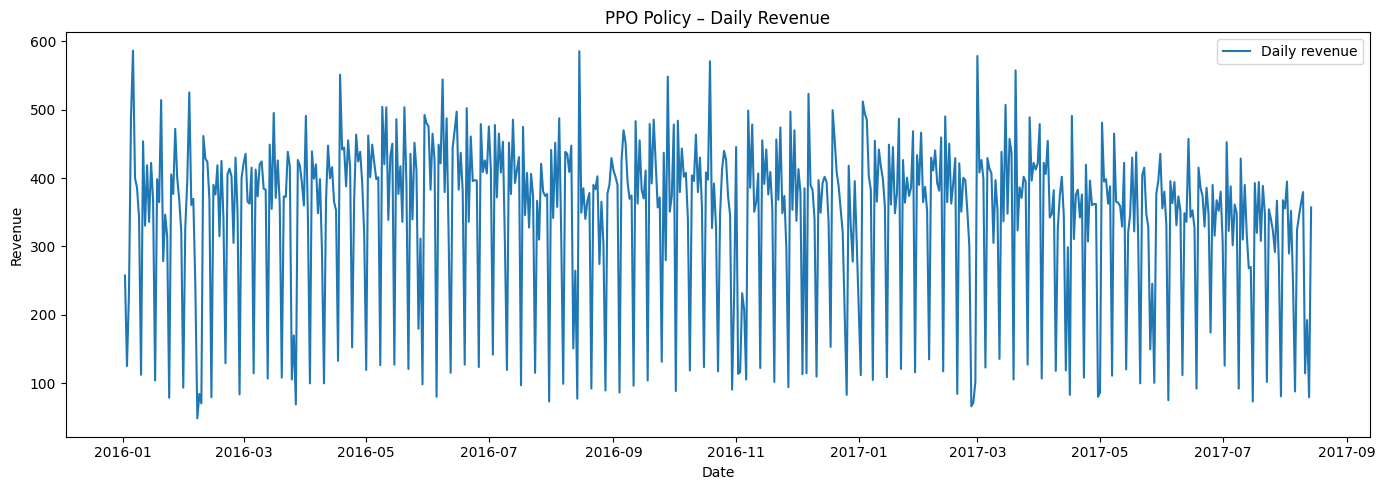

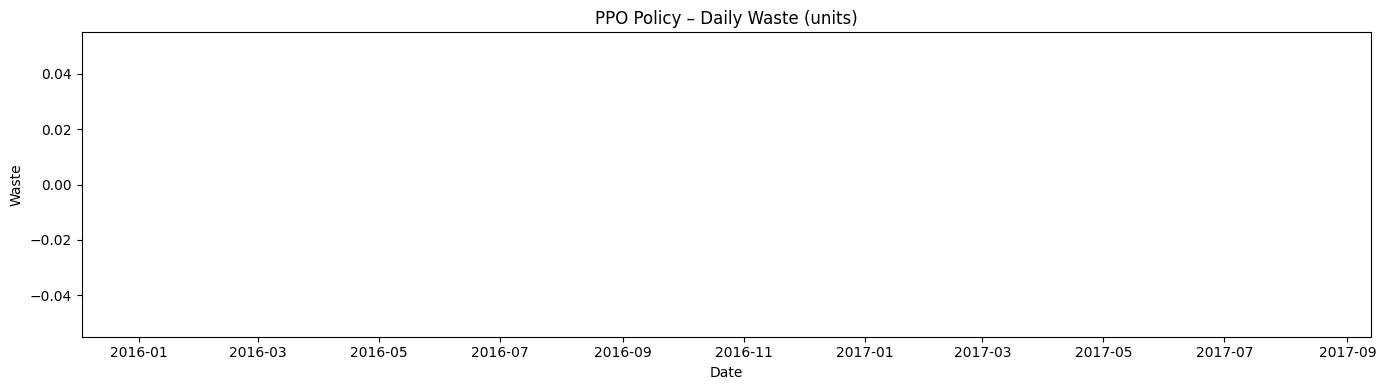


Action counts:
action
1    589
Name: count, dtype: int64


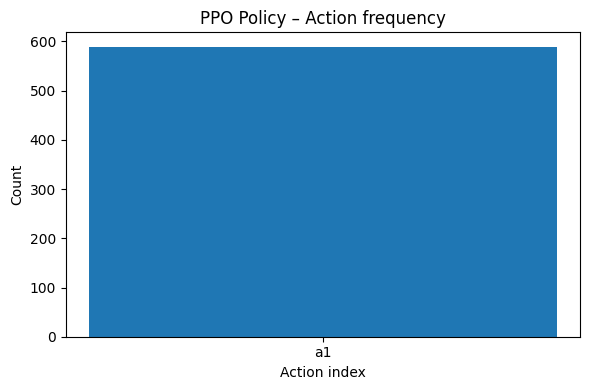

In [7]:
import matplotlib.pyplot as plt

# 2.1 Revenue and waste over time
plt.figure(figsize=(14, 5))
plt.plot(rl_df["date"], rl_df["revenue"], label="Daily revenue")
plt.title("PPO Policy – Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.savefig("daily_revenue_policy.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 4))
plt.bar(rl_df["date"], rl_df["waste"])
plt.title("PPO Policy – Daily Waste (units)")
plt.xlabel("Date")
plt.ylabel("Waste")
plt.tight_layout()
plt.show()

# 2.2 Action usage (how often each price is chosen)
action_counts = rl_df["action"].value_counts().sort_index()
print("\nAction counts:")
print(action_counts)

plt.figure(figsize=(6, 4))
plt.bar(action_counts.index, action_counts.values)
plt.xticks(action_counts.index, [f"a{i}" for i in action_counts.index])
plt.title("PPO Policy – Action frequency")
plt.xlabel("Action index")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [8]:
def run_policy(env_config, policy_fn, name="policy"):
    env = PricingEnv(**env_config)
    obs, info = env.reset()

    records = []

    for t in range(env.n_days - 1):
        action = policy_fn(env, obs, t)
        obs, reward, done, truncated, info = env.step(int(action))

        records.append({
            "day": t,
            "date": info["date"],
            "action": int(action),
            "price": info["effective_price"],
            "sold": info["sold"],
            "waste": info["waste"],
            "inventory": info["inventory"],
            "revenue": info["revenue"],
            "reward": reward,
            "base_demand": info["base_demand"],
            "order_qty": info["order_qty"],
        })

        if done:
            break

    df_out = pd.DataFrame(records)
    print(f"\n=== {name} ===")
    print("Total days:   ", len(df_out))
    print("Total revenue:", df_out['revenue'].sum())
    print("Total waste:  ", df_out['waste'].sum())
    print("Total reward: ", df_out['reward'].sum())
    return df_out


In [9]:
env_config = dict(
    df=df,
    price_multipliers=[0.5, 0.7, 1.0, 1.1],
    base_price=1.0,
    elasticity=0.8,
    shelf_life=3,
    safety_stock_factor=1.3,
    waste_penalty=2.0,
    max_inventory=5000,
    random_seed=42,
)


In [10]:
# Fixed-price policy: always action 2 (no discount)
def fixed_policy(env, obs, t):
    return 2

# Random policy
def random_policy(env, obs, t):
    return env.action_space.sample()

# PPO policy using your trained model
def ppo_policy(env, obs, t):
    action, _ = model.predict(obs, deterministic=True)
    return int(action)


In [11]:
fixed_df = run_policy(env_config, fixed_policy, name="Fixed price (action=2)")
random_df = run_policy(env_config, random_policy, name="Random policy")
ppo_df   = run_policy(env_config, ppo_policy,   name="PPO policy")



=== Fixed price (action=2) ===
Total days:    589
Total revenue: 244636.0
Total waste:   45156
Total reward:  154324.0

=== Random policy ===
Total days:    589
Total revenue: 220117.50043720007
Total waste:   9436
Total reward:  201245.50043720007

=== PPO policy ===
Total days:    589
Total revenue: 203194.59653961658
Total waste:   0
Total reward:  203194.59653961658


In [12]:
summary = pd.DataFrame({
    "policy": ["fixed", "random", "ppo"],
    "revenue": [
        fixed_df["revenue"].sum(),
        random_df["revenue"].sum(),
        ppo_df["revenue"].sum(),
    ],
    "waste": [
        fixed_df["waste"].sum(),
        random_df["waste"].sum(),
        ppo_df["waste"].sum(),
    ],
    "reward": [
        fixed_df["reward"].sum(),
        random_df["reward"].sum(),
        ppo_df["reward"].sum(),
    ],
})

summary

,policy,revenue,waste,reward
0,fixed,244636.000000,45156,154324.000000
1,random,220117.500437,9436,201245.500437
2,ppo,203194.596540,0,203194.596540


In [13]:
###### import numpy as np

# === Multi-seed evaluation ===
def evaluate_multi_seed(env_config, seeds=(0, 1, 2, 3, 4)):
    """
    Run fixed, random, and PPO policies over multiple random seeds
    and collect total revenue, waste, and reward.
    """
    rows = []

    for seed in seeds:
        cfg = {**env_config, "random_seed": seed}

        for policy_name, policy_fn in [
            ("fixed", fixed_policy),
            ("random", random_policy),
            ("ppo",   ppo_policy),
        ]:
            df_run = run_policy(cfg, policy_fn, name=f"{policy_name}_seed_{seed}")

            rows.append({
                "seed": seed,
                "policy": policy_name,
                "total_revenue": df_run["revenue"].sum(),
                "total_waste":   df_run["waste"].sum(),
                "total_reward":  df_run["reward"].sum(),
            })

    results_df = pd.DataFrame(rows)
    return results_df


results_df = evaluate_multi_seed(env_config, seeds=range(5))

# Save for report
results_df.to_csv("policy_comparison.csv", index=False)

# Show averaged metrics per policy
results_df.groupby("policy")[["total_revenue", "total_waste", "total_reward"]].mean()



=== fixed_seed_0 ===
Total days:    589
Total revenue: 246325.0
Total waste:   43450
Total reward:  159425.0

=== random_seed_0 ===
Total days:    589
Total revenue: 220309.50050663948
Total waste:   9835
Total reward:  200639.50050663948

=== ppo_seed_0 ===
Total days:    589
Total revenue: 203121.09654086828
Total waste:   0
Total reward:  203121.09654086828

=== fixed_seed_1 ===
Total days:    589
Total revenue: 245762.0
Total waste:   44030
Total reward:  157702.0

=== random_seed_1 ===
Total days:    589
Total revenue: 219268.20059996843
Total waste:   7300
Total reward:  204668.20059996843

=== ppo_seed_1 ===
Total days:    589
Total revenue: 203182.69653981924
Total waste:   0
Total reward:  203182.69653981924

=== fixed_seed_2 ===
Total days:    589
Total revenue: 246063.0
Total waste:   43710
Total reward:  158643.0

=== random_seed_2 ===
Total days:    589
Total revenue: 219763.10044634342
Total waste:   6109
Total reward:  207545.10044634342

=== ppo_seed_2 ===
Total days: 

,total_revenue,total_waste,total_reward
policy,,,
fixed,246090.400000,43703.0,158684.400000
ppo,203182.976540,0.0,203182.976540
random,220362.460563,8335.6,203691.260563


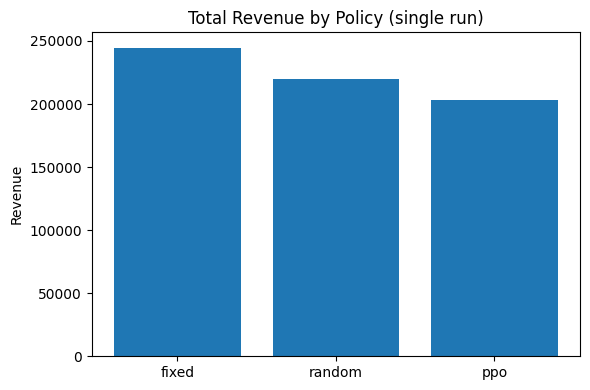

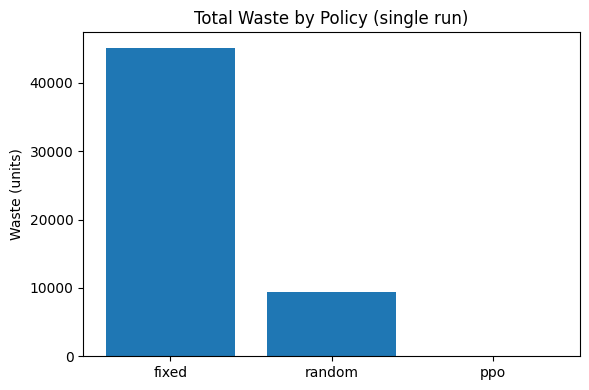

In [14]:
# === Visualisation: Summary bar charts (single run) ===
plt.figure(figsize=(6, 4))
plt.bar(summary["policy"], summary["revenue"])
plt.title("Total Revenue by Policy (single run)")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(summary["policy"], summary["waste"])
plt.title("Total Waste by Policy (single run)")
plt.ylabel("Waste (units)")
plt.tight_layout()
plt.show()


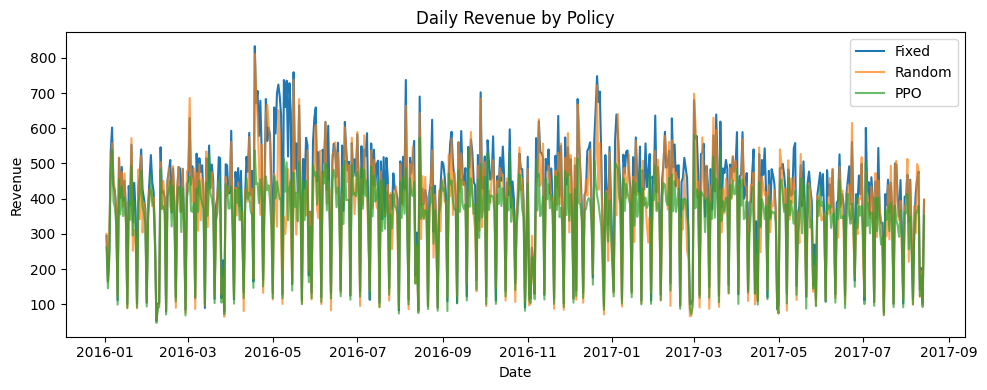

In [15]:
# === Visualisation: Daily revenue over time ===
plt.figure(figsize=(10, 4))
plt.plot(fixed_df["date"], fixed_df["revenue"], label="Fixed")
plt.plot(random_df["date"], random_df["revenue"], label="Random", alpha=0.7)
plt.plot(ppo_df["date"],   ppo_df["revenue"],   label="PPO",    alpha=0.7)
plt.title("Daily Revenue by Policy")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()


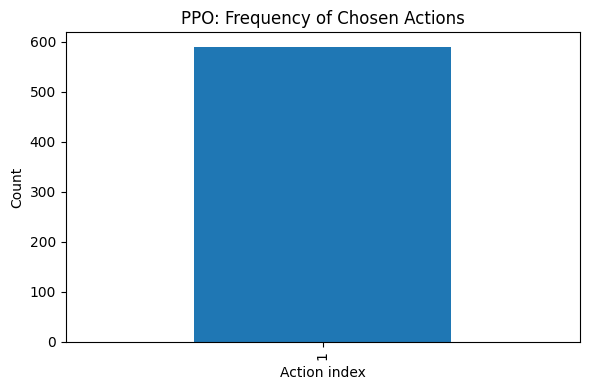

In [16]:
# === Visualisation: PPO action distribution ===
plt.figure(figsize=(6, 4))
ppo_df["action"].value_counts().sort_index().plot(kind="bar")
plt.title("PPO: Frequency of Chosen Actions")
plt.xlabel("Action index")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


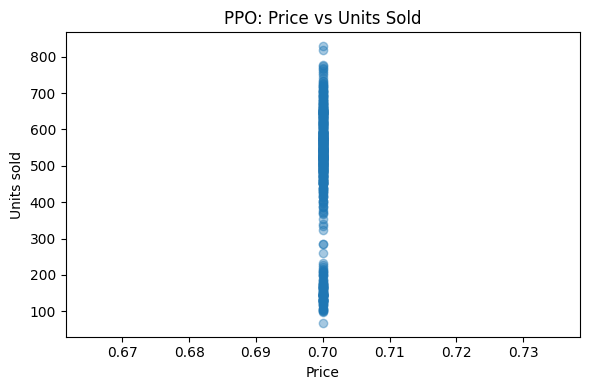

In [17]:
# === Visualisation: PPO price vs sold ===
plt.figure(figsize=(6, 4))
plt.scatter(ppo_df["price"], ppo_df["sold"], alpha=0.4)
plt.title("PPO: Price vs Units Sold")
plt.xlabel("Price")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()


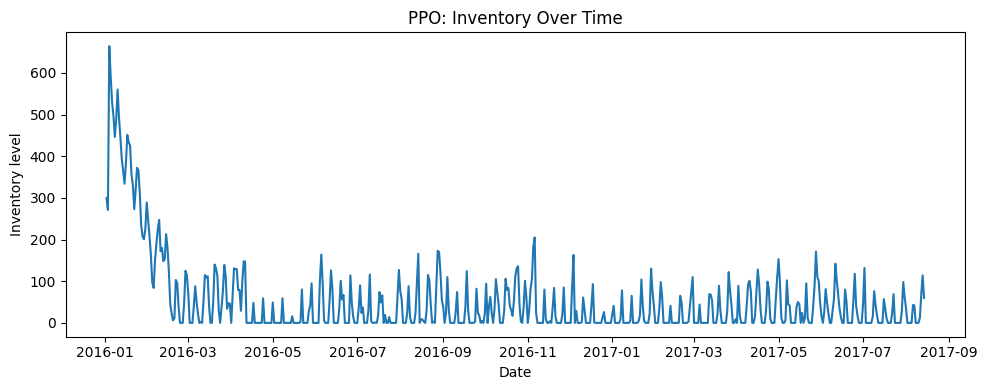

In [18]:
# === Visualisation: PPO inventory trajectory ===
plt.figure(figsize=(10, 4))
plt.plot(ppo_df["date"], ppo_df["inventory"])
plt.title("PPO: Inventory Over Time")
plt.xlabel("Date")
plt.ylabel("Inventory level")
plt.tight_layout()
plt.show()


In [19]:
import numpy as np
import pandas as pd

# === Multi-seed evaluation of fixed, random, and PPO policies ===

def evaluate_policies_multi_seed(env_config, seeds=range(5)):
    """
    Run fixed, random, and PPO policies over multiple random seeds.
    For each (seed, policy) it rolls out one full episode using run_policy()
    and collects total revenue, waste, and reward.

    Returns:
        results_df: DataFrame with columns:
            ['seed', 'policy', 'total_revenue', 'total_waste', 'total_reward']
    """
    rows = []

    for seed in seeds:
        cfg = dict(env_config)  # shallow copy
        cfg["random_seed"] = seed

        for policy_name, policy_fn in [
            ("fixed", fixed_policy),
            ("random", random_policy),
            ("ppo",   ppo_policy),
        ]:
            df_run = run_policy(cfg, policy_fn, name=f"{policy_name}_seed_{seed}")

            rows.append({
                "seed":          seed,
                "policy":        policy_name,
                "total_revenue": df_run["revenue"].sum(),
                "total_waste":   df_run["waste"].sum(),
                "total_reward":  df_run["reward"].sum(),
            })

    results_df = pd.DataFrame(rows)
    return results_df


# === Run experiment and save results ===

seeds = range(5)  # e.g. 5 seeds: 0,1,2,3,4

results_df = evaluate_policies_multi_seed(env_config, seeds=seeds)

# Save for later analysis / report
results_df.to_csv("policy_comparison.csv", index=False)

print("Raw results per seed & policy:")
display(results_df)

print("\nAverage metrics per policy across seeds:")
policy_summary = (
    results_df
    .groupby("policy")[["total_revenue", "total_waste", "total_reward"]]
    .mean()
    .round(2)
)
display(policy_summary)



=== fixed_seed_0 ===
Total days:    589
Total revenue: 246325.0
Total waste:   43450
Total reward:  159425.0

=== random_seed_0 ===
Total days:    589
Total revenue: 221382.80062699318
Total waste:   9153
Total reward:  203076.80062699318

=== ppo_seed_0 ===
Total days:    589
Total revenue: 203121.09654086828
Total waste:   0
Total reward:  203121.09654086828

=== fixed_seed_1 ===
Total days:    589
Total revenue: 245762.0
Total waste:   44030
Total reward:  157702.0

=== random_seed_1 ===
Total days:    589
Total revenue: 218454.40022051334
Total waste:   7163
Total reward:  204128.40022051334

=== ppo_seed_1 ===
Total days:    589
Total revenue: 203182.69653981924
Total waste:   0
Total reward:  203182.69653981924

=== fixed_seed_2 ===
Total days:    589
Total revenue: 246063.0
Total waste:   43710
Total reward:  158643.0

=== random_seed_2 ===
Total days:    589
Total revenue: 218474.50058561563
Total waste:   5479
Total reward:  207516.50058561563

=== ppo_seed_2 ===
Total days: 

,seed,policy,total_revenue,total_waste,total_reward
0,0,fixed,246325.000000,43450,159425.000000
1,0,random,221382.800627,9153,203076.800627
2,0,ppo,203121.096541,0,203121.096541
3,1,fixed,245762.000000,44030,157702.000000
4,1,random,218454.400221,7163,204128.400221
5,1,ppo,203182.696540,0,203182.696540
6,2,fixed,246063.000000,43710,158643.000000
7,2,random,218474.500586,5479,207516.500586
8,2,ppo,203163.096540,0,203163.096540
9,3,fixed,246185.000000,43627,158931.000000



Average metrics per policy across seeds:


,total_revenue,total_waste,total_reward
policy,,,
fixed,246090.40,43703.0,158684.40
ppo,203182.98,0.0,203182.98
random,219246.42,7056.8,205132.82


C:\Users\suman\AppData\Local\Temp\ipykernel_33124\182861993.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Fixed","Random","PPO"], showmeans=True, meanline=True, whis=1.5)


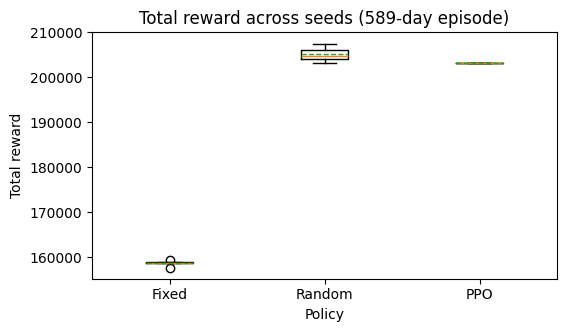

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# results_df already exists with columns: seed, policy, total_revenue, total_waste, total_reward

policy_order = ["fixed", "random", "ppo"]
results_df["policy"] = pd.Categorical(results_df["policy"], policy_order, ordered=True)

fig, ax = plt.subplots(figsize=(6, 3.2))
data = [results_df.loc[results_df["policy"] == p, "total_reward"].values
        for p in policy_order]

bp = ax.boxplot(data, labels=["Fixed","Random","PPO"], showmeans=True, meanline=True, whis=1.5)
ax.set_title("Total reward across seeds (589-day episode)")
ax.set_xlabel("Policy")
ax.set_ylabel("Total reward")

plt.savefig("reward_distribution_boxplot.png", dpi=300, bbox_inches="tight")   # or SVG
plt.show()
